# Demo: tra cứu một kỹ năng

Chọn **kỹ năng** và **địa điểm** → xem: bao nhiêu tin yêu cầu, tỷ lệ có công bố lương, phân bố dải lương (Low/Mid/High), các kỹ năng hay đi kèm (lift), và nhóm nghề tuyển kỹ năng đó.

**Cách chạy (≤ 2 phút):** `pip install -r requirements.txt` → mở notebook → *Run All* → chọn trong dropdown.

**Dữ liệu cần có:** `data/processed/jobs_clean.parquet` và `data/processed/skill_matrix.parquet` (tải từ Drive, hoặc chạy `python scripts/run_pipeline.py skills`). Hash phải khớp `docs/MANIFEST.json`.

Notebook chỉ hiển thị số liệu tổng hợp, **không** in nguyên văn JD (cam kết ToS, `docs/DECISIONS.md` 29/09).

In [1]:
import sys
from pathlib import Path

# Chạy được dù mở notebook từ thư mục gốc repo hay từ notebooks/
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.viz.eda import FIGURES, load_data, save_figure, salary_tertiles, skill_share

# load_data() kiểm SHA-256 của jobs_clean + skill_matrix với docs/MANIFEST.json, lệch thì dừng
jobs, skills = load_data()
print(f"{len(jobs)} tin, {skills.shape[1]} kỹ năng — hash khớp docs/MANIFEST.json")

import ipywidgets as widgets

labels, (low, high) = salary_tertiles(jobs)
jobs["salary_class"] = labels  # NaN với tin không có lương
CITIES = {"Tất cả": None, "TP.HCM": "loc_hcm", "Hà Nội": "loc_hn", "Đà Nẵng": "loc_dn"}
share = skill_share(skills)
print(f"Dải lương (tertile): Low < {low:.1f} ≤ Mid < {high:.1f} ≤ High (triệu VND/tháng)")

688 tin, 100 kỹ năng — hash khớp docs/MANIFEST.json
Dải lương (tertile): Low < 32.2 ≤ Mid < 50.0 ≤ High (triệu VND/tháng)


python — Tất cả: 175/688 tin (25.4%); có công bố lương: 49
Lương trung vị: 38.7 triệu VND/tháng


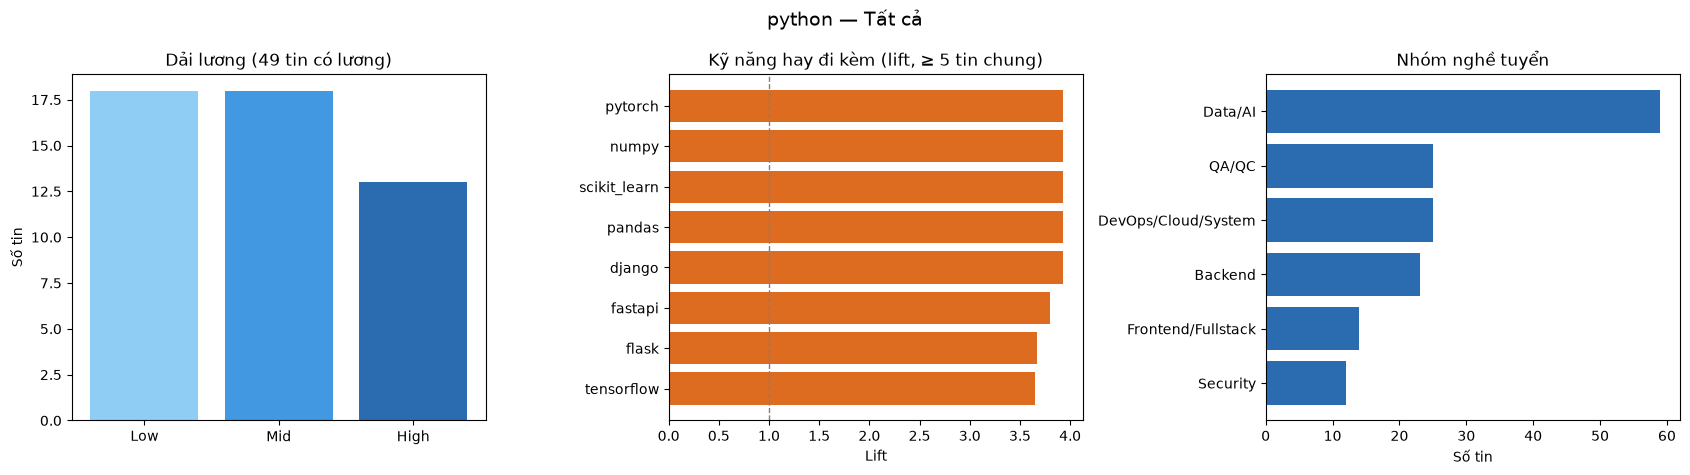

In [2]:
def explore(skill, city):
    scope = jobs.index if CITIES[city] is None else jobs.index[jobs[CITIES[city]] == 1]
    sk = skills.loc[scope]
    has_skill = sk[skill] == 1
    sub = jobs.loc[scope][has_skill]
    n, n_scope = len(sub), len(scope)
    if n == 0:
        print("Không có tin nào."); return
    paid = sub[sub["has_salary"]]
    print(f"{skill} — {city}: {n}/{n_scope} tin ({n / n_scope:.1%}); có công bố lương: {len(paid)}")
    if len(paid):
        print(f"Lương trung vị: {paid['salary_mid'].median():.1f} triệu VND/tháng"
              + ("  ⚠️ ít mẫu (< 10 tin)" if len(paid) < 10 else ""))

    # kỹ năng đi kèm: lift = P(B|skill) / P(B), chỉ tính kỹ năng xuất hiện ≥ 5 tin cùng skill
    together = sk[has_skill].sum().drop(skill)
    lift = (together / n) / sk.mean().drop(skill)
    lift = lift[together >= 5].sort_values(ascending=False).head(8)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    dist = paid["salary_class"].value_counts().reindex(["Low", "Mid", "High"], fill_value=0)
    axes[0].bar(dist.index, dist.values, color=["#90cdf4", "#4299e1", "#2b6cb0"])
    axes[0].set_title(f"Dải lương ({len(paid)} tin có lương)"); axes[0].set_ylabel("Số tin")
    axes[1].barh(lift.index[::-1], lift.values[::-1], color="#dd6b20")
    axes[1].axvline(1, color="grey", linestyle="--", linewidth=1)
    axes[1].set_title("Kỹ năng hay đi kèm (lift, ≥ 5 tin chung)"); axes[1].set_xlabel("Lift")
    groups = sub["expertise_group"].value_counts().head(6)
    axes[2].barh(groups.index[::-1], groups.values[::-1], color="#2b6cb0")
    axes[2].set_title("Nhóm nghề tuyển"); axes[2].set_xlabel("Số tin")
    fig.suptitle(f"{skill} — {city}", fontsize=14)
    fig.tight_layout()
    plt.show()



# Ví dụ tĩnh (hiện cả khi xem notebook trên GitHub, nơi widget không chạy)
explore("python", "Tất cả")

### Tự chọn

Đổi kỹ năng / địa điểm trong dropdown (cần chạy notebook trong Jupyter).

In [3]:
skill_options = [s for s in share.index if skills[s].sum() >= 10]  # đủ tin để có ý nghĩa
widgets.interact(
    explore,
    skill=widgets.Dropdown(options=skill_options, value="python", description="Kỹ năng"),
    city=widgets.Dropdown(options=list(CITIES), value="Tất cả", description="Địa điểm"),
);

interactive(children=(Dropdown(description='Kỹ năng', index=8, options=('english', 'communication', 'api', 'ci…

Số liệu trong demo là tổng hợp theo kỹ năng; không hiển thị tin riêng lẻ hay nội dung JD.